In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Find the project root from the notebook's working directory.
cwd = Path.cwd().resolve()

project_root = next(
    (
        folder
        for folder in [cwd, *cwd.parents]
        if (folder / "requirements.txt").is_file()
        and (folder / "data" / "processed").is_dir()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("Could not locate the project folder.")

data_path = (
    project_root
    / "data"
    / "processed"
    / "ftse100_modelling_dataset.csv"
)

data = pd.read_csv(
    data_path,
    index_col="Date",
    parse_dates=["Date"],
)

figures_folder = project_root / "outputs" / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

print("Observations:", len(data))
print("First date:", data.index.min().date())
print("Last date:", data.index.max().date())

Observations: 6736
First date: 2000-01-04
Last date: 2026-08-28


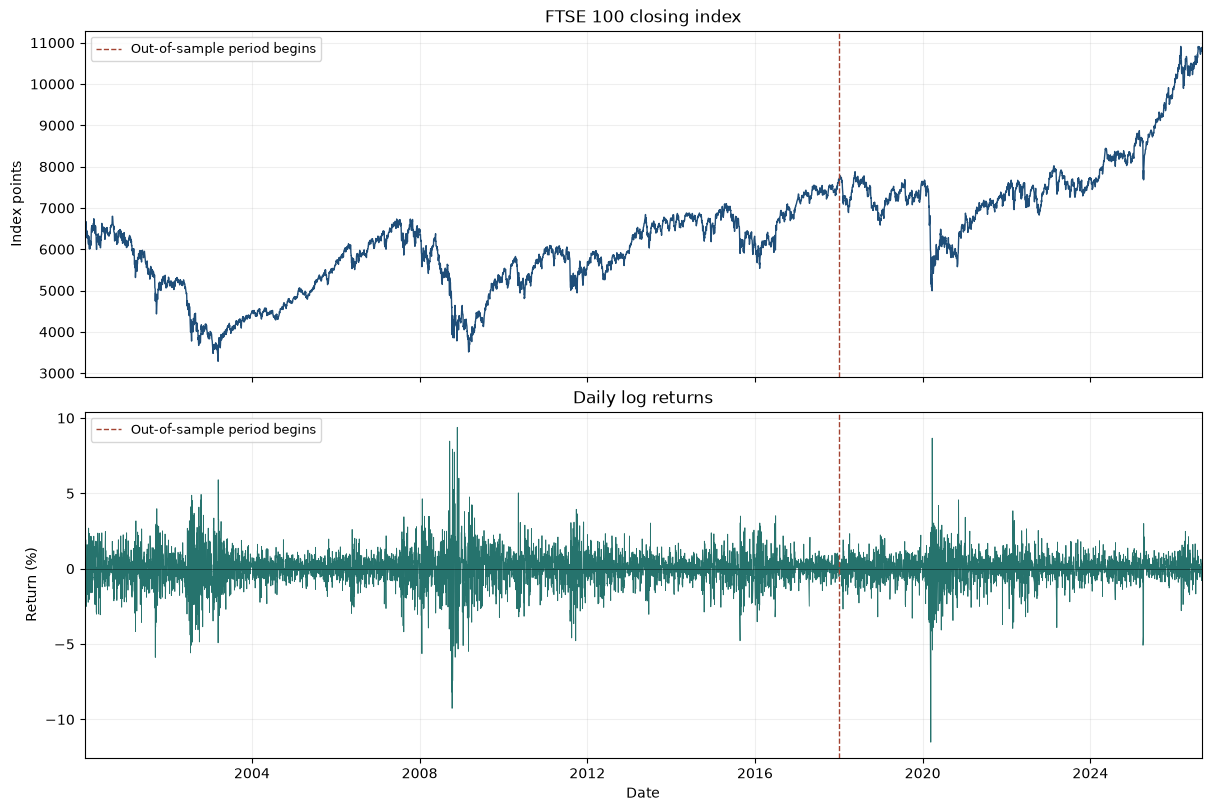

Saved: /Users/lohith/Documents/GitHub/FTSE100-Volatility-Garch/outputs/figures/ftse100_prices_and_returns.png


In [2]:
forecast_start = pd.Timestamp("2018-01-01")

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    constrained_layout=True,
)

# Top panel: closing index level.
axes[0].plot(
    data.index,
    data["Close"],
    color="#1f4e79",
    linewidth=1,
)
axes[0].set_title("FTSE 100 closing index")
axes[0].set_ylabel("Index points")

# Bottom panel: daily percentage log returns.
axes[1].plot(
    data.index,
    data["return_pct"],
    color="#26736d",
    linewidth=0.6,
)
axes[1].axhline(
    0,
    color="black",
    linewidth=0.6,
    alpha=0.5,
)
axes[1].set_title("Daily log returns")
axes[1].set_ylabel("Return (%)")
axes[1].set_xlabel("Date")

# Mark the planned start of out-of-sample forecasting.
for ax in axes:
    ax.axvline(
        forecast_start,
        color="#a34332",
        linestyle="--",
        linewidth=1,
        label="Out-of-sample period begins",
    )
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left", fontsize=9)

axes[1].set_xlim(data.index.min(), data.index.max())

figure_path = figures_folder / "ftse100_prices_and_returns.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", figure_path)

In [3]:
train = data.loc["2000-01-01":"2017-12-31"].copy()
test = data.loc["2018-01-01":].copy()

sample_summary = pd.DataFrame({
    "observations": [len(train), len(test)],
    "first_date": [
        train.index.min().date(),
        test.index.min().date(),
    ],
    "last_date": [
        train.index.max().date(),
        test.index.max().date(),
    ],
}, index=["Training", "Out-of-sample"])

display(sample_summary)

,observations,first_date,last_date
Training,4548,2000-01-04,2017-12-29
Out-of-sample,2188,2018-01-02,2026-08-28


In [4]:
r_train = train["return_pct"]

return_summary = pd.Series({
    "Observations": r_train.count(),
    "Mean (%)": r_train.mean(),
    "Median (%)": r_train.median(),
    "Standard deviation (%)": r_train.std(ddof=1),
    "Minimum (%)": r_train.min(),
    "1st percentile (%)": r_train.quantile(0.01),
    "5th percentile (%)": r_train.quantile(0.05),
    "95th percentile (%)": r_train.quantile(0.95),
    "99th percentile (%)": r_train.quantile(0.99),
    "Maximum (%)": r_train.max(),
    "Skewness": r_train.skew(),
    "Excess kurtosis": r_train.kurt(),
}, name="Training sample")

display(return_summary.to_frame().round(4))

tables_folder = project_root / "outputs" / "tables"
tables_folder.mkdir(parents=True, exist_ok=True)

return_summary.to_csv(
    tables_folder / "training_return_summary.csv",
    index_label="Statistic",
)

,Training sample
Observations,4548.0000
Mean (%),0.0023
Median (%),0.0380
Standard deviation (%),1.1928
Minimum (%),-9.2645
1st percentile (%),-3.4508
5th percentile (%),-1.8979
95th percentile (%),1.8111
99th percentile (%),3.0985
Maximum (%),9.3842


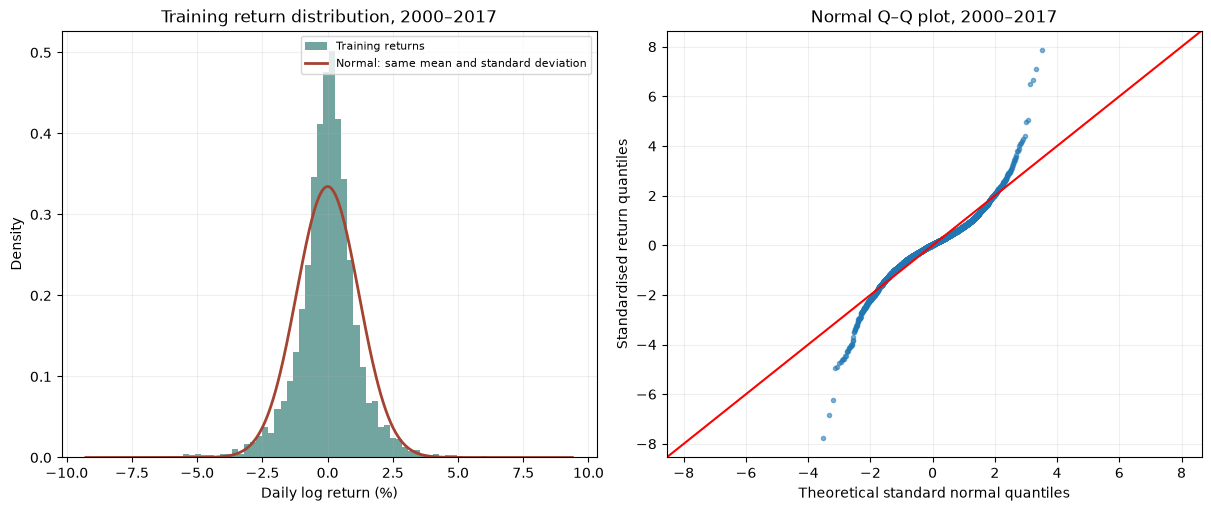

Saved: /Users/lohith/Documents/GitHub/FTSE100-Volatility-Garch/outputs/figures/training_return_distribution.png


In [5]:
import numpy as np
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot

mean_return = r_train.mean()
std_return = r_train.std(ddof=1)

# Standardise using the training sample's mean and standard deviation.
# This is for visualisation, not GARCH model residuals.
z_train = (r_train - mean_return) / std_return

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    constrained_layout=True,
)

# Histogram and normal reference density.
axes[0].hist(
    r_train,
    bins=80,
    density=True,
    color="#26736d",
    alpha=0.65,
    label="Training returns",
)

x = np.linspace(r_train.min(), r_train.max(), 600)

axes[0].plot(
    x,
    norm.pdf(x, loc=mean_return, scale=std_return),
    color="#a34332",
    linewidth=2,
    label="Normal: same mean and standard deviation",
)

axes[0].set_title("Training return distribution, 2000–2017")
axes[0].set_xlabel("Daily log return (%)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# Compare standardised returns with standard normal quantiles.
qqplot(
    z_train.to_numpy(),
    dist=norm,
    fit=False,
    line="45",
    ax=axes[1],
    marker="o",
    markersize=3,
    alpha=0.55,
    color="#1f4e79",
)

axes[1].set_title("Normal Q–Q plot, 2000–2017")
axes[1].set_xlabel("Theoretical standard normal quantiles")
axes[1].set_ylabel("Standardised return quantiles")

for ax in axes:
    ax.grid(alpha=0.2)

figure_path = figures_folder / "training_return_distribution.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", figure_path)

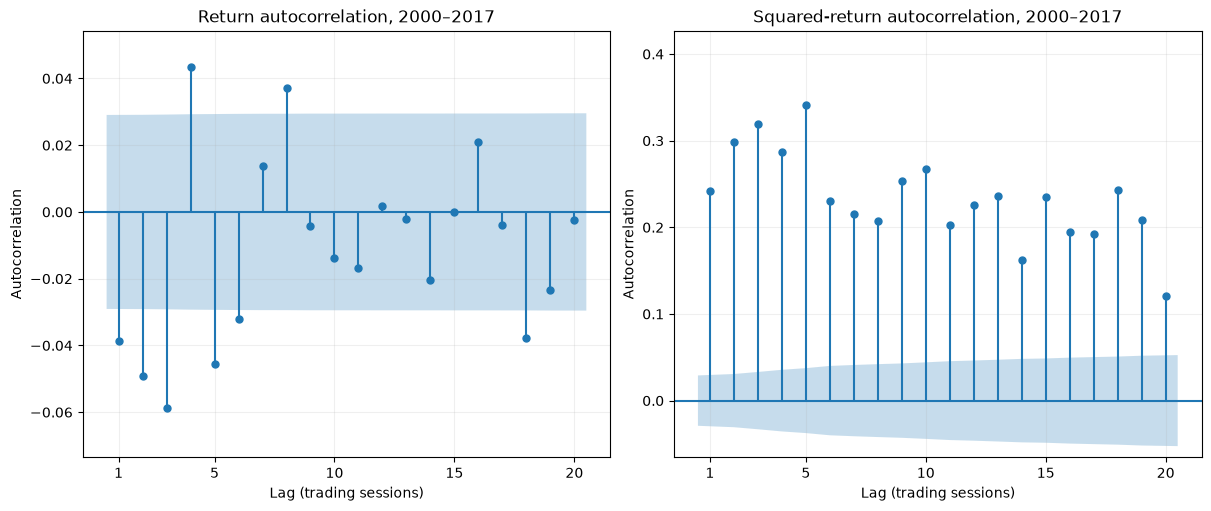

Saved: /Users/lohith/Documents/GitHub/FTSE100-Volatility-Garch/outputs/figures/training_return_acf.png


In [6]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    constrained_layout=True,
)

plot_acf(
    r_train,
    lags=20,
    zero=False,
    alpha=0.05,
    auto_ylims=True,
    ax=axes[0],
    title="Return autocorrelation, 2000–2017",
)

plot_acf(
    r_train ** 2,
    lags=20,
    zero=False,
    alpha=0.05,
    auto_ylims=True,
    ax=axes[1],
    title="Squared-return autocorrelation, 2000–2017",
)

for ax in axes:
    ax.set_xlabel("Lag (trading sessions)")
    ax.set_ylabel("Autocorrelation")
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.grid(alpha=0.2)

figure_path = figures_folder / "training_return_acf.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", figure_path)

In [7]:
from statsmodels.stats.diagnostic import acorr_ljungbox

diagnostic_lags = [5, 10, 20]

lb_returns = acorr_ljungbox(
    r_train,
    lags=diagnostic_lags,
    model_df=0,
    return_df=True,
)

lb_squared = acorr_ljungbox(
    r_train ** 2,
    lags=diagnostic_lags,
    model_df=0,
    return_df=True,
)

lb_results = pd.concat(
    {
        "Returns": lb_returns,
        "Squared returns": lb_squared,
    },
    names=["Series", "Lag"],
)

display(
    lb_results.style.format({
        "lb_stat": "{:.3f}",
        "lb_pvalue": "{:.3e}",
    })
)

lb_results.to_csv(
    tables_folder / "training_ljung_box.csv"
)

In [8]:
from statsmodels.stats.diagnostic import het_arch

# Residuals from a constant-mean model, using training data only.
mean_residuals = r_train - r_train.mean()

arch_rows = []

for lag in [5, 10, 20]:
    # ddof=1 accounts for the estimated mean parameter.
    result = het_arch(
        mean_residuals.to_numpy(),
        nlags=lag,
        ddof=1,
    )

    # First four outputs: LM statistic, LM p-value,
    # F statistic and F p-value.
    lm_stat, lm_pvalue, f_stat, f_pvalue = result[:4]

    arch_rows.append({
        "Lag": lag,
        "LM statistic": lm_stat,
        "LM p-value": lm_pvalue,
        "F statistic": f_stat,
        "F p-value": f_pvalue,
    })

arch_results = pd.DataFrame(arch_rows).set_index("Lag")

display(
    arch_results.style.format({
        "LM statistic": "{:.3f}",
        "LM p-value": "{:.3e}",
        "F statistic": "{:.3f}",
        "F p-value": "{:.3e}",
    })
)

arch_results.to_csv(
    tables_folder / "training_arch_lm.csv"
)

/Users/lohith/Documents/GitHub/FTSE100-Volatility-Garch/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


,LM statistic,LM p-value,F statistic,F p-value
Lag,,,,
5,992.749,2.232e-212,253.806,8.724e-240
10,1057.858,6.394e-221,137.647,3.469e-252
20,1165.153,2.115e-234,78.102,1.256e-272
